# B-mode_simulation code

### 1) Some library imports

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

We import some libraries like:
* numpy -> that is a library for scientific calculations
* matplotlib -> that is a library for data visualization
* scipy(hilbert) -> this is a function that will be used for the envelope extraction

### 2) Parameters

In [40]:
c = 1520  #speed of sound in the human body in m/s.            
fs = 100e6  #frequency sampling set to 100 MHz (100.000.000 cicles for second).
depth_max = 0.06  #depth_max is set to 6 cm.  
t = np.arange(0, (2 * depth_max) / c, 1/fs)  #is a cronometer which mark the times (start, stop, step).
n_elements = 128   #number of elements in our probe.
distance_elements = 0.015 #distance between the elements on the probe
x_array = np.linspace(-distance_elements, distance_elements, n_elements) #Represent the horizontal configuration of our channels.
pulse_duration = -0.5 #duration of the impulse



The initial parameter settings are among the most important aspects of this code. The sampling frequency(fs) is set to 100 MHz which means that data is acquired every 10 ns. The depth_max is set to 6 cm which means that when we will see the visualization window, we could see that the signal deepness will be set to 6 cm (z coordinate ↓). The time (t) parameter start to 0 and we can notice that depth_max is multiplied for 2 (because the sound goes through the depth 2 times, the first from the probe to the object and the second from the object to the probe). The horizontal configuration of channels is equally distributed along the all probe lenght, from -1.5 cm to 1.5 cm that are 3 cm. So finally we will have a 3 x 6 cm visualization window (3 cm along the x axis and 6 cm along the z axis).

### 3) Phantom generation

In [24]:
n_scatterers = 60000  #Number of scatterers.
x_s = np.random.uniform(-0.02, 0.02, n_scatterers) #Distribution of speckle by uniform way along the x axis.
z_s = np.random.uniform(0.01, depth_max, n_scatterers) #Distribution of speckle by uniform way along the z axis.
amps = np.random.normal(0, 0.3, n_scatterers) #Defines how much bright the speckles are.

The speckles are a very little elements that create the texture of a human part that has smaller elements then the wavelenght. 
The distribution of scatterers is formatted like (from, to, n_scatterers) and amps (reflected signal, contrast, n_scatterers).

We have some mask that they can be applied to the scatterers to have different cyst's shapes:

#### a) Horizontal line mask

In [25]:
line_x_start, line_x_end = -0.01, 0.01  #the line strarts from -1 cm and finish to 1 cm (2 cm)
line_z_coord, line_thick = 0.055, 0.0008  #the z coord for the line is 5.5 cm depth and the thickness is 0.08 cm

line_mask = ~((z_s > line_z_coord - line_thick/2) & (z_s < line_z_coord + line_thick/2) & \
           (x_s > line_x_start) & (x_s < line_x_end))  

x_s, z_s, amps = x_s[line_mask], z_s[line_mask], amps[line_mask] #the application of the line_mask

In this part of script we are trying to simulate some different shape type of cysts. In this case we are trying to simulate a horizontal line shape. The line_mask is a mask which is used to delete the speckles inside the line cyst. After the creation of this mask we have to apply it on the scatterers. 

#### b) Vertical line mask

In [26]:
line_z_start, line_z_end = 0.02, 0.04  #the line starts from 2 cm and finish to 4 cm (2cm)
line_x_coord, line_thick_v = 0.012, 0.0010 #the x coord for the line is 1.2 cm from the left side of the graph

line_mask2 = ~((x_s > line_x_coord - line_thick_v/2) & (x_s < line_x_coord + line_thick_v/2) & \
           (z_s > line_z_start) & (z_s < line_z_end))  
x_s, z_s, amps = x_s[line_mask2], z_s[line_mask2], amps[line_mask2] #the application of the line_mask2

In this part of script we have the same situation as before but now the line is in a vertical shape.

#### c) Square mask

In [27]:
sq_x_center = 0.0   #the position of the square's center on the x axis.
sq_z_center = 0.03   #the position of the square's center on the z axis.    
sq_side = 0.01   #square side set to 1 cm.       


sq_x_start = sq_x_center - sq_side/2  #this is position of the start side line to x axis 
sq_x_end   = sq_x_center + sq_side/2  #this is position of the end side line to x axis
sq_z_start = sq_z_center - sq_side/2  #this is position of the start side line to z axis
sq_z_end   = sq_z_center + sq_side/2  #this is position of the end side line to z axis

square_mask = ~((x_s > sq_x_start) & (x_s < sq_x_end) & \
                (z_s > sq_z_start) & (z_s < sq_z_end))

x_s, z_s, amps = x_s[square_mask], z_s[square_mask], amps[square_mask] #the applicationof the square_mask


In this code lines we are creating another shape of cyst, the square. The functionality is like the same as lines cyst but instead of to set some value for the start and the end of the line, here we have set only the center of the square and with this we have set the position of the line in bases of the position of the square's center.

### 3) Impulse

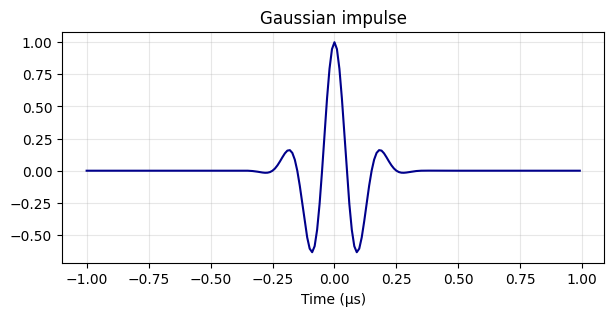

As we can see, we have the peak when the impulse is at 0 µs


In [42]:
f0 = 5e6 #impulse frequency set to 5 x 10^6 (5 MHz)
t_min, t_max = -1e-6, 1e-6
pulse_t = np.arange(t_min, t_max, 1/fs) #impulse duration set to -1 microsecond to 1 (2 microseconds)
et = np.exp(pulse_duration * (pulse_t / 0.10e-6)**2) * np.cos(2 * np.pi * f0 * pulse_t) #the creation of the impulse
plt.figure(figsize=(7, 3))
plt.plot(pulse_t * 1e6, et, color='darkblue')
plt.title("Gaussian impulse")
plt.xlabel("Time (µs)")
plt.grid(True, alpha=0.3)
plt.show()

print('As we can see, we have the peak when the impulse is at 0 µs')


Here we are creating the wave's pulse. To calculate the impulse we have to multiply the envelope for the cosine and this calculation is done in the et object:
* np.exp(pulse_duration * (pulse_t / 0.10e-6)**2) -> this is the rapresentation of our evelope.
* np.cos(2 * np.pi * f0 * pulse_t) -> this is the wave.


If we multiply evelope * cosine, we will have the pulse. 


### 4) Simulation

#### The faster solution

In [29]:
print("Simulating scan lines (optimized)...")
for i, x_tx in enumerate(x_array):
    rf_line = np.zeros_like(t)
    
    
    distances = np.sqrt((x_tx - x_s)**2 + z_s**2) #calculate the distance between the x_tx cristal and the cyst scatteres
    taus = (2 * distances) / c #convert the distance in time
    idx_taus = np.round(taus * fs).astype(int) #search the nearest index at tau time in t
    weights = amps * np.exp(-((x_tx - x_s)**2) / (0.0003**2)) #if the scatterer is perfectly under the cristal the weight will be 1 = 100%
    
    
    for k in range(len(x_s)):  #this is the iteration for the scatterers
        start = idx_taus[k] - len(et)//2 #we are centering the peak of the impulse to the 0 ns time point
        end = start + len(et)
        
        if 0 <= start and end < len(rf_line):
            rf_line[start:end] += et * weights[k]
            
    b_mode_matrix[:, i] = np.abs(hilbert(rf_line))


Simulating scan lines (optimized)...


#### The older solution

In [19]:
b_mode_matrix = np.zeros((len(t), n_elements)) #this row of code generate the space where we will see our result

print("Simulating scan lines...")  #vectorization with np
for i, x_tx in enumerate(x_array): 
    rf_line = np.zeros_like(t) #create a column of zeros in the x_tx position with deepness of t 
    for xs, zs, amp in zip(x_s, z_s, amps): 
        dist = np.sqrt((x_tx - xs)**2 + zs**2) #calculate the distance between the x_tx cristal and the cyst scatteres
        tau = (2 * dist) / c #convert the distance in time
        idx_tau = np.argmin(np.abs(t - tau)) #search the nearest index at tau time in t
        start_idx = idx_tau - len(et)//2 #we are centering the peak of the impulse to the 0 ns time point
        end_idx = start_idx + len(et)
        
        if 0 <= start_idx and end_idx < len(rf_line): 
            
            lateral_weight = np.exp(-((x_tx - xs)**2) / (0.0003**2)) #if the scatterer is perfectly under the cristal the weight will be 1 = 100%
            rf_line[start_idx:end_idx] += et * amp * lateral_weight #linear sum where I simulate the return sound waves
            

    b_mode_matrix[:, i] = np.abs(hilbert(rf_line)) #Here we have to use the hilbert function to get the envelope

    

Simulating scan lines...


This is the hardest part of code because here we have simulate all the signal for each element on the probe.

* for i, x_tx in enumerate(x_array): -> index of element (i), element physical location (x_tx)
* for xs, zs, amp in zip(x_s, z_s, amps): -> takes one at a time for all of them and the zip command associates x_s (horizontal position), z_s (deepness), amps (eco)
* idx_tau -> search the nearest index at tau time in t




* start_idx = idx_tau - len(et)//2 -> we are centring the signal start from the index less the half of the impulse;
* end_idx = start_idx + len(et) -> from the start we are adding all the signal to set the end;
* if 0 <= start_idx and end_idx < len(rf_line): -> sum the echos if they are inside our time window;
* lateral_weight = np.exp(-((x_tx - xs)^2) / (0.0003^2)) -> horizontal distance between the cristal and the scatterer (x_tx - xs, lenght of my element on the probe (0.0005);
* rf_line[start_idx:end_idx] += et * amp * lateral_weight -> += we use this convention because in the locations under or on to of the scatterers we have also others scatterers which emit some echos, so each echo is summed or they cancel it selfs if they are out of phase, with other scatterers echos;
* We use the Hilbert's formula to find the upper side signal envelope.

  #### how it works?
  When the transducer recieves the wave generate another wave out of phase to 90° and after this the trasducer marks the new envelope. And we use only the upper side of the envelope (we give it from np.abs) because is the only side that we use for calculations.

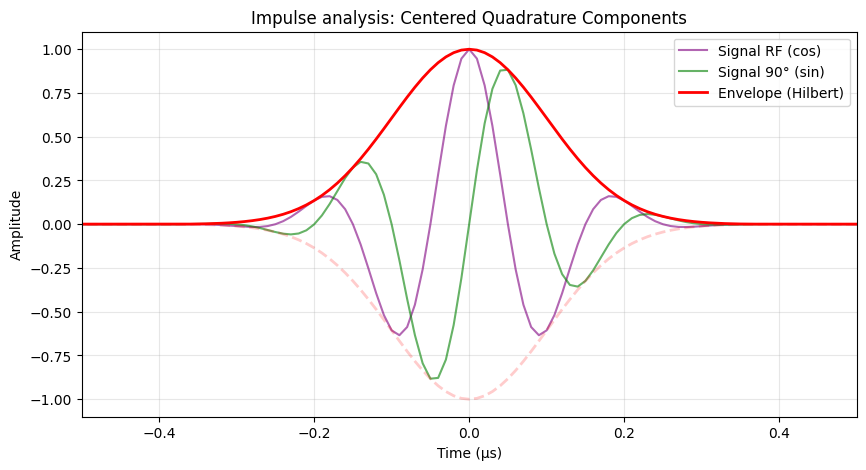

In [34]:
  
t_min, t_max = -1e-6, 1e-6
num_points = int((t_max - t_min) * fs) + 1 
pulse_t = np.linspace(t_min, t_max, num_points) 
f0 = 5e6   


et = np.exp(-0.5 * (pulse_t / 0.10e-6)**2) * np.cos(2 * np.pi * f0 * pulse_t)
analytic_signal = hilbert(et)
quadrature_signal = np.imag(analytic_signal) 
amplitude_envelope = np.abs(analytic_signal) 


plt.figure(figsize=(10, 5))
plt.plot(pulse_t * 1e6, et, color='purple', alpha=0.6, label='Signal RF (cos)')
plt.plot(pulse_t * 1e6, quadrature_signal, color='green', alpha=0.6, label='Signal 90° (sin)')
plt.plot(pulse_t * 1e6, amplitude_envelope, color='red', linewidth=2, label='Envelope (Hilbert)')
plt.plot(pulse_t * 1e6, -amplitude_envelope, color='red', linewidth=2, linestyle='--', alpha=0.2)

plt.xlim([-0.5, 0.5]) 
plt.title("Impulse analysis: Centered Quadrature Components")
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()


### 5) Visualization

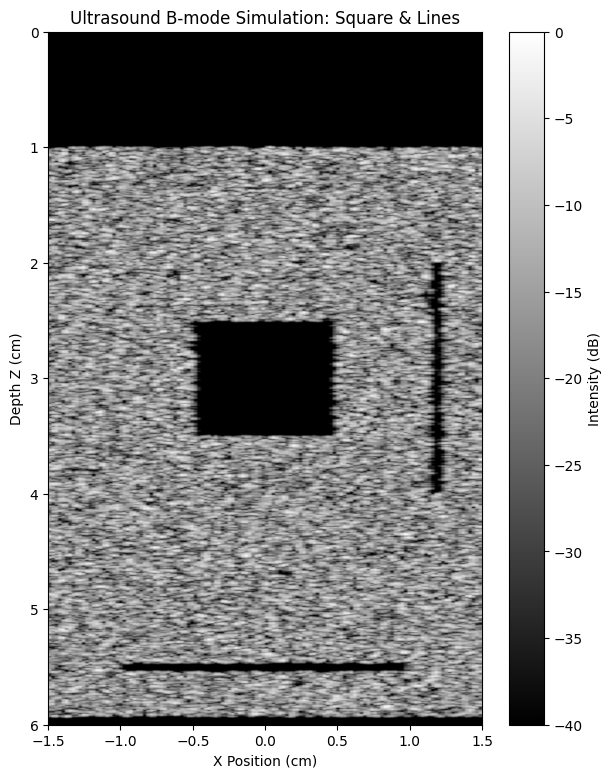

In [30]:
plt.figure(figsize=(7, 9))
# Convert to dB scale; +1e-6 prevents log(0). 
image_data = 20 * np.log10(b_mode_matrix + 1e-6) 
image_data -= np.max(image_data) # Normalize to 0 dB

plt.imshow(image_data, aspect='auto', cmap='gray', vmin=-40, vmax=0,
           extent=[x_array[0]*100, x_array[-1]*100, depth_max*100, 0])

plt.title("Ultrasound B-mode Simulation: Square & Lines")
plt.xlabel("X Position (cm)")
plt.ylabel("Depth Z (cm)")
plt.colorbar(label="Intensity (dB)")
plt.show()